# Graph link-prediction — `full_full` dataset (LORAX / Hladis M2OR)

> **v5 — финальный, честный протокол.** Независимые cold-молекулярные сиды, message passing только на train-рёбрах, для энкодера хранятся оба снапшота (best-val AUPRC и last-epoch), тест не подсматривается во время обучения GNN. Это итоговые результаты, не предварительные.

The most complete M2OR variant we have. Node features: **putative ESM-1b 650M mean** (proteins, distinct from curated/full ESM2; identity pending verification) + **ChemBERTa-77M** (molecules; the LORAX paper shows the molecule encoder is interchangeable, GIN covers only 64%). Reported head: unentangled **XGBoost** probe on `[raw ChemBERTa mol ‖ graph-enriched ESM prot]`.

**Two regimes** (rows of every plot):

- **transductive** — LORAX folds as-is: train/val = full noisy mix, test = EC50-only edges (~22% pos). All nodes known, edges held out (≈ stratified).
- **inductive_molecule** — cold start: whole molecules held out of the graph entirely, tested on their EC50 pairs (≈ group_molecule). Built in `orbind/lorax.py`; test stays EC50-only.

Grey bar = our plain `ESM‖ChemBERTa → XGBoost` baseline **on the same split, no graph** (`scripts/modeling/eval/eval_full_full_baseline.py`).

In [82]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from orbind.dataset import metrics

FOLD = 1   # which LORAX random fold to display (1..5)
# Clean stable-recipe grid ({gnn,gat} x {pos_only,all_edges,signed} x regimes),
# produced by scripts/modeling/train/run_graph_grid_v3.ps1 (same lr 1e-3 / grad-clip /
# ReduceLROnPlateau recipe as graph_rerun_v3; best_state restored before probe).
# The old provisional sweep (300ep, no best-val, default lr) is kept at
# results/graph/full_full/legacy/pre_v5/provisional_and_900_pilot/checkpoints — switch CKPT_DIR back to inspect it.
CKPT_DIR = ROOT / "results" / "graph" / "legacy" / "full_full" / "sweep_v3" / "full_full" / "checkpoints"
BASELINE_CSV = ROOT / "results" / "full_full" / "tables" / "baselines.csv"
REGIMES = ["transductive", "inductive_molecule"]
PLOT_METRICS = ["AUROC", "AUPRC", "MCC", "F1"]


def variant_of(ckpt):
    c = ckpt["config"]; v = c["mp_mode"]
    q = c.get("mol_quality_q", 0) or 0
    if q > 0: v += f"_q{int(q*100)}"
    if c.get("history", False):
        v += "_history" if c.get("history_depth", 2) >= 2 else "_hist1"
    if c.get("concat_raw_prot", False): v += "_rawp"
    if c.get("transductive_exp", False): v += "_transductive_exp"
    if c.get("disjoint_probe_train", False): v += "_disjoint"
    return v


print("ckpt_dir =", CKPT_DIR, "| fold =", FOLD)

ckpt_dir = <repo>\results\graph\legacy\full_full\sweep_v3\full_full\checkpoints | fold = 1


## v5 — complete 900-epoch architecture screen

Primary protocol: **last checkpoint**, 900 epochs, no test evaluation during GNN training. Cache-miss reruns use lr=3e-3 and gradient clipping at 1.0; message passing uses the standard unfiltered graph, shared training data, and a raw-molecule XGBoost probe. Two encoder snapshots are retained: best validation AUPRC and last epoch; the primary probe uses the last snapshot.

Grid: `{GNN, GAT} × {positive-only, all-edges, signed} × {transductive, inductive molecule}`. Transductive evaluation uses three genuine LORAX folds; inductive evaluation uses three independent cold-molecule seeds. GNN and XGBoost receive distinct seeds, for **36 runs** total. Pre-v5 artifacts are isolated under `results/graph/full_full/legacy/`; this screen lives under `results/graph/full_full/v5/architecture_screen/`.


v5 completed: 36/36; collapse-masked: 0; last used: 36; best probes: 36/28


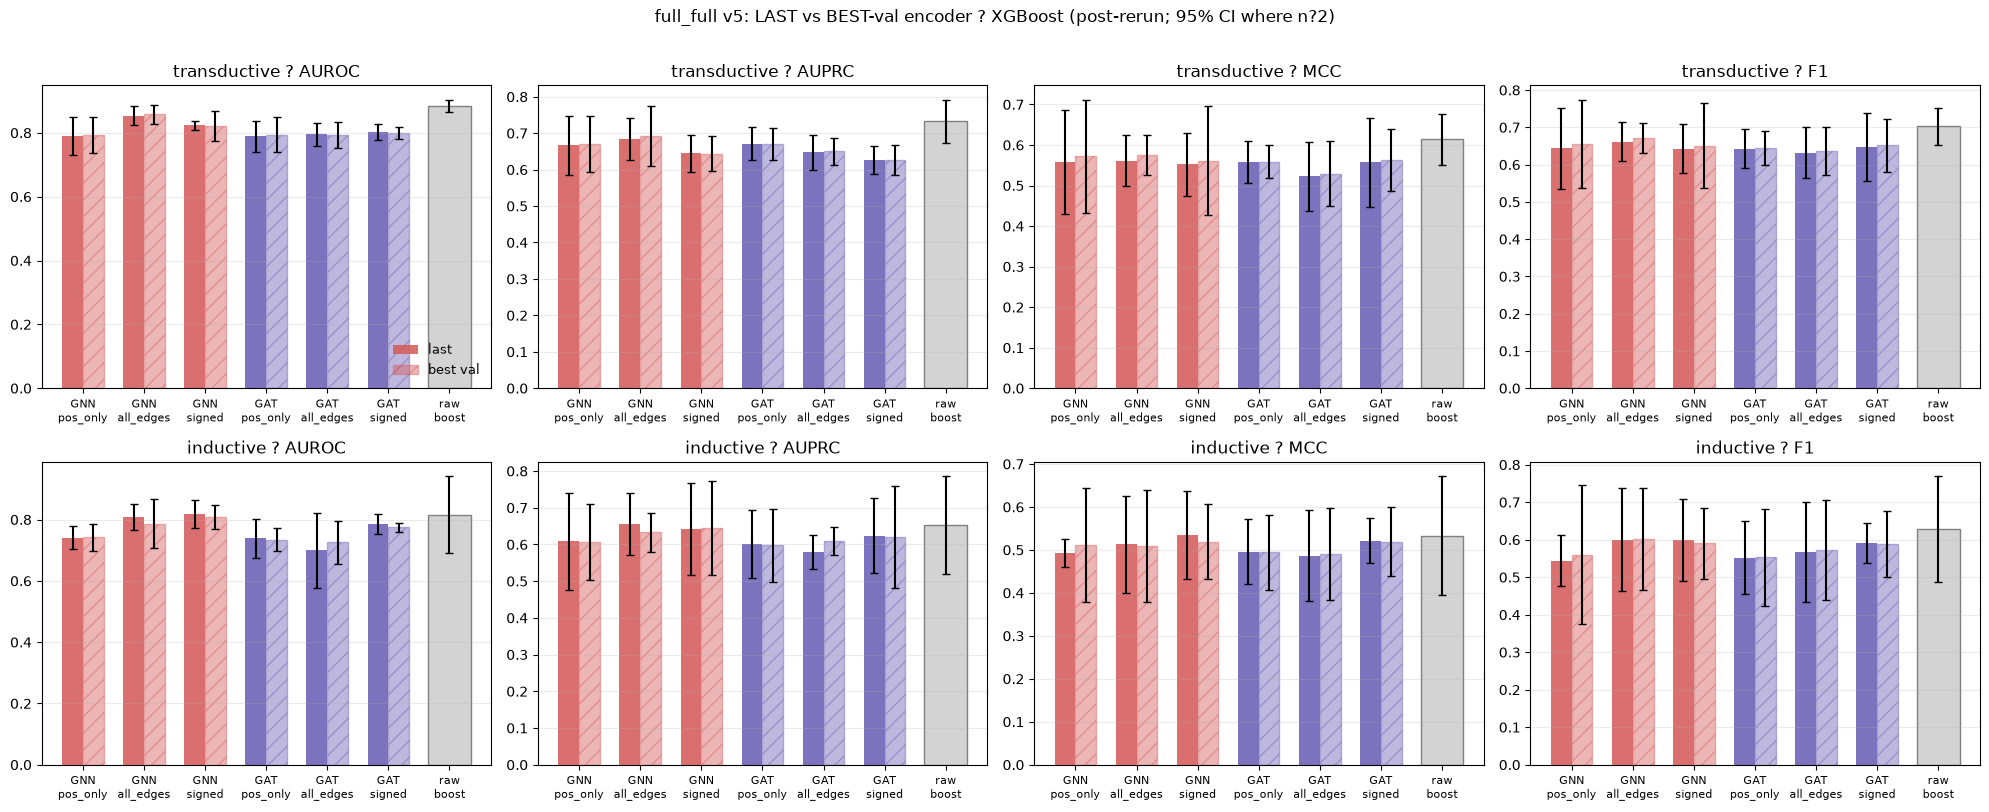

[Large run table omitted; rerun the cell to inspect the full table.]

In [85]:
# Load completed v5 runs and build the first architecture-comparison figure.
from scipy.stats import t as student_t

V5_ROOT = ROOT / "results/graph/full_full/v5/architecture_screen"
V5_CKPT = V5_ROOT / "training/checkpoints"
V5_BEST_PROBE = V5_ROOT / "probes/best_checkpoint"
V5_TABLES = V5_ROOT / "reports/tables"
V5_TABLES.mkdir(parents=True, exist_ok=True)

rows = []
if V5_CKPT.exists():
    for path in sorted(V5_CKPT.glob("*.pt")):
        ck = torch.load(path, map_location="cpu", weights_only=False)
        scores = ck.get("test_scores_final")
        if scores is None:
            continue
        y = ck["test_sup"][1].numpy()
        vals = metrics(y, np.asarray(scores))
        rows.append({
            "regime": ck["regime"], "arch": ck["arch"],
            "mp_mode": ck["config"]["mp_mode"], "fold": ck["fold"],
            "gnn_seed": ck.get("gnn_seed", ck.get("seed")),
            "boost_seed": ck.get("boost_seed"), "path": str(path), **vals,
        })

v5_runs_all = pd.DataFrame(rows)

# Runs excluded from aggregate statistics because their validation trajectory
# shows a persistent collapse, a terminal cliff, or strong collapse-like instability.
HISTORICAL_COLLAPSE_KEYS = {
    ("transductive", "gnn", "pos_only", 1, 42),
    ("transductive", "gnn", "signed", 1, 42),
    ("transductive", "gnn", "signed", 3, 44),
    ("transductive", "gnn", "all_edges", 2, 43),
    ("inductive_molecule", "gnn", "pos_only", 1, 43),
    ("inductive_molecule", "gnn", "pos_only", 1, 44),
    ("inductive_molecule", "gnn", "signed", 1, 42),
    ("inductive_molecule", "gnn", "signed", 1, 43),
}

# All eight targeted lr=3e-3 + clip=1.0 reruns passed the trajectory review.
COLLAPSE_MASK = set()

def collapse_key(row):
    return (row.regime, row.arch, row.mp_mode, int(row.fold), int(row.gnn_seed))

if len(v5_runs_all):
    suspect = v5_runs_all.apply(lambda row: collapse_key(row) in COLLAPSE_MASK, axis=1)
    excluded_runs = v5_runs_all[suspect].copy()
    v5_runs = v5_runs_all[~suspect].copy()
else:
    excluded_runs = v5_runs_all.copy()
    v5_runs = v5_runs_all.copy()

best_rows = []
if V5_BEST_PROBE.exists():
    for path in sorted(V5_BEST_PROBE.glob("*.pt")):
        rec = torch.load(path, map_location="cpu", weights_only=False)
        key = (rec["regime"], rec["arch"], rec["mp_mode"], int(rec["fold"]), int(rec["gnn_seed"]))
        if key in COLLAPSE_MASK:
            continue
        best_rows.append({
            "regime": rec["regime"], "arch": rec["arch"], "mp_mode": rec["mp_mode"],
            "fold": rec["fold"], "gnn_seed": rec["gnn_seed"],
            "boost_seed": rec["boost_seed"], "best_epoch": rec["best_epoch"],
            **{m: float(rec["test_metrics_best"][m]) for m in PLOT_METRICS},
        })
best_runs = pd.DataFrame(best_rows)

print(f"v5 completed: {len(v5_runs_all)}/36; collapse-masked: {len(excluded_runs)}; "
      f"last used: {len(v5_runs)}; best probes: {len(best_runs)}/28")
if len(v5_runs):
    summary = []
    for keys, group in v5_runs.groupby(["regime", "arch", "mp_mode"]):
        for metric in PLOT_METRICS:
            x = group[metric].astype(float)
            n = len(x); mean = x.mean(); sd = x.std(ddof=1) if n > 1 else np.nan
            half = (student_t.ppf(.975, n - 1) * sd / np.sqrt(n)) if n > 1 else np.nan
            summary.append(dict(zip(["regime", "arch", "mp_mode"], keys)) |
                           {"metric": metric, "mean": mean, "sd": sd, "n": n,
                            "ci_low": mean-half, "ci_high": mean+half})
    v5_summary = pd.DataFrame(summary)

    best_summary_rows = []
    if len(best_runs):
        for keys, group in best_runs.groupby(["regime", "arch", "mp_mode"]):
            for metric in PLOT_METRICS:
                x = group[metric].astype(float)
                n = len(x); mean = x.mean(); sd = x.std(ddof=1) if n > 1 else np.nan
                half = (student_t.ppf(.975, n - 1) * sd / np.sqrt(n)) if n > 1 else np.nan
                best_summary_rows.append(dict(zip(["regime", "arch", "mp_mode"], keys)) |
                                         {"metric": metric, "mean": mean, "sd": sd, "n": n,
                                          "ci_low": mean-half, "ci_high": mean+half})
    best_summary = pd.DataFrame(best_summary_rows)
    v5_runs.to_csv(V5_TABLES / "architecture_runs.csv", index=False)
    if len(best_runs):
        best_runs.to_csv(V5_TABLES / "architecture_best_checkpoint_runs.csv", index=False)
        best_summary.to_csv(V5_TABLES / "architecture_best_checkpoint_summary_ci95.csv", index=False)
    excluded_runs.to_csv(V5_TABLES / "excluded_collapse_runs.csv", index=False)
    v5_summary.to_csv(V5_TABLES / "architecture_summary_ci95.csv", index=False)

    # Matched raw-boost reference: exactly LORAX folds 1..3 for transductive
    # and exactly cold seeds 42..44 for inductive, matching the v5 repeats.
    baseline_runs = pd.read_csv(ROOT / "results/full_full/tables/baseline_runs.csv")
    matched = pd.concat([
        baseline_runs[(baseline_runs.regime == "transductive") &
                      (baseline_runs["repeat"].isin([1, 2, 3]))],
        baseline_runs[(baseline_runs.regime == "inductive_molecule") &
                      (baseline_runs["split_seed"].isin([42, 43, 44]))],
    ], ignore_index=True)
    baseline_rows = []
    for regime, group in matched.groupby("regime"):
        for metric in PLOT_METRICS:
            x = group[metric].astype(float); n = len(x); mean = x.mean(); sd = x.std(ddof=1)
            half = student_t.ppf(.975, n-1) * sd / np.sqrt(n)
            baseline_rows.append({"regime": regime, "metric": metric, "mean": mean,
                                  "ci_low": mean-half, "ci_high": mean+half, "n": n})
    baseline = pd.DataFrame(baseline_rows)
    labels = [("gnn", "pos_only"), ("gnn", "all_edges"), ("gnn", "signed"),
              ("gat", "pos_only"), ("gat", "all_edges"), ("gat", "signed")]
    colors = {"gnn": "#D65F5F", "gat": "#6F63B6"}
    width = .34
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]
            sub_last = v5_summary[(v5_summary.regime == regime) & (v5_summary.metric == metric)]
            sub_best = (best_summary[(best_summary.regime == regime) & (best_summary.metric == metric)]
                        if len(best_summary) else best_summary)
            for xi, (arch, mp) in enumerate(labels):
                q = sub_last[(sub_last.arch == arch) & (sub_last.mp_mode == mp)]
                if len(q):
                    row = q.iloc[0]
                    err = None if row.n < 2 else [[row["mean"]-row.ci_low], [row.ci_high-row["mean"]]]
                    ax.bar(xi-width/2, row["mean"], width=width, color=colors[arch], alpha=.9,
                           yerr=err, capsize=3 if err is not None else 0,
                           label="last" if ri == 0 and mi == 0 and xi == 0 else None)
                q = sub_best[(sub_best.arch == arch) & (sub_best.mp_mode == mp)] if len(sub_best) else sub_best
                if len(q):
                    row = q.iloc[0]
                    err = None if row.n < 2 else [[row["mean"]-row.ci_low], [row.ci_high-row["mean"]]]
                    ax.bar(xi+width/2, row["mean"], width=width, color=colors[arch], alpha=.45,
                           hatch="//", edgecolor=colors[arch],
                           yerr=err, capsize=3 if err is not None else 0,
                           label="best val" if ri == 0 and mi == 0 and xi == 0 else None)
            b = baseline[(baseline.regime == regime) & (baseline.metric == metric)]
            if len(b):
                br = b.iloc[0]; xi = len(labels)
                ax.bar(xi, br["mean"], width=.7, color="lightgray", edgecolor="gray",
                       yerr=[[br["mean"]-br.ci_low], [br.ci_high-br["mean"]]], capsize=3)
            ax.set_xticks(range(len(labels)+1))
            ax.set_xticklabels([f"{a.upper()}\n{m}" for a,m in labels] + ["raw\nboost"],
                               rotation=0, fontsize=8)
            ax.set_title(f"{regime.replace('_molecule','')} ? {metric}")
            ax.grid(axis="y", alpha=.25)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle("full_full v5: LAST vs BEST-val encoder ? XGBoost (post-rerun; 95% CI where n?2)", y=1.01)
    fig.tight_layout()
    plt.show()

    # Compact mean-results table after collapse masking (plus the matched raw baseline).
    graph_means = (v5_runs.groupby(["regime", "arch", "mp_mode"], as_index=False)
                   .agg(n=("AUPRC", "size"),
                        AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                        MCC=("MCC", "mean"), F1=("F1", "mean")))
    graph_means["checkpoint"] = "last"
    if len(best_runs):
        best_means = (best_runs.groupby(["regime", "arch", "mp_mode"], as_index=False)
                      .agg(n=("AUPRC", "size"),
                           AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                           MCC=("MCC", "mean"), F1=("F1", "mean")))
        best_means["checkpoint"] = "best_val"
        graph_means = pd.concat([graph_means, best_means], ignore_index=True)
    baseline_means = (matched.groupby("regime", as_index=False)
                      .agg(n=("AUPRC", "size"),
                           AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                           MCC=("MCC", "mean"), F1=("F1", "mean")))
    baseline_means["arch"] = "baseline"
    baseline_means["mp_mode"] = "raw_boost"
    baseline_means["checkpoint"] = "raw"
    mean_results = (pd.concat([graph_means, baseline_means], ignore_index=True)
                    [["regime", "arch", "mp_mode", "checkpoint", "n", *PLOT_METRICS]]
                    .sort_values(["regime", "arch", "mp_mode", "checkpoint"]))
    mean_results.to_csv(V5_TABLES / "mean_results_collapse_masked.csv", index=False)
    display(mean_results.style.format({m: "{:.3f}" for m in PLOT_METRICS}).hide(axis="index"))
else:
    print("No v5 result bundles yet; run the launcher cell first.")


## v5 quantile screen - 5-repeat aggregation

Reads the server-side quantile sweep from `results/graph/full_full/v5/quantile_screen/training/checkpoints` and aggregates over five repeat points:

- transductive: LoRaX folds 1..5;
- inductive_molecule: cold-molecule seeds 42..46.

The table keeps both probe checkpoints (`best_val`, `last_epoch`); the plot uses `QUANTILE_PLOT_CHECKPOINT` below.


In [ ]:
# v5 quantile screen: bar-grid summary for GNN all_edges/signed over 5 repeat points.
# Reads completed checkpoints only; it does not launch training.

from scipy.stats import t as student_t

QS_ROOT = ROOT / "results/graph/full_full/v5/quantile_screen"
QS_TRAIN = QS_ROOT / "training"
QS_CKPT = QS_TRAIN / "checkpoints"
QS_TABLES = QS_ROOT / "reports/tables"
QS_FIGURES = QS_ROOT / "reports/figures"
QS_TABLES.mkdir(parents=True, exist_ok=True)
QS_FIGURES.mkdir(parents=True, exist_ok=True)

EXPECTED_REPEATS = {
    "transductive": {1, 2, 3, 4, 5},
    "inductive_molecule": {42, 43, 44, 45, 46},
}
EXPECTED_MP_MODES = ["all_edges", "signed"]
EXPECTED_QS = [0.0, 0.87, 0.95, 0.99]
CHECKPOINT_SCORE_KEYS = {
    "best_val": "test_scores",
    "last_epoch": "test_scores_final",
}
QUANTILE_PLOT_CHECKPOINT = "last_epoch"  # switch to "best_val" if needed


def _as_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _q_clean(q):
    return round(float(q or 0.0), 2)


def _q_label(q):
    q = _q_clean(q)
    return "q0" if q == 0.0 else f"q{int(round(q * 100))}"


def _repeat_id(ck):
    # Transductive repeats are real LoRaX folds; inductive repeats are cold split seeds.
    if ck["regime"] == "transductive":
        return int(ck["fold"])
    return int(ck.get("gnn_seed", ck.get("seed")))


def _ci95_half(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return float(student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x)))


quantile_rows = []
if QS_CKPT.exists():
    for path in sorted(QS_CKPT.glob("gnn_*_unentangled_boost_*.pt")):
        ck = torch.load(path, map_location="cpu", weights_only=False)
        cfg = ck.get("config", {})
        regime = ck.get("regime")
        mp_mode = cfg.get("mp_mode", ck.get("mp_mode"))
        q = _q_clean(cfg.get("mol_quality_q", 0.0))
        if ck.get("arch") != "gnn" or regime not in EXPECTED_REPEATS:
            continue
        if mp_mode not in EXPECTED_MP_MODES or q not in EXPECTED_QS:
            continue

        y = _as_numpy(ck["test_sup"][1])
        for checkpoint, score_key in CHECKPOINT_SCORE_KEYS.items():
            scores = ck.get(score_key)
            if scores is None:
                continue
            vals = metrics(y, _as_numpy(scores))
            quantile_rows.append({
                "regime": regime,
                "checkpoint": checkpoint,
                "arch": ck.get("arch"),
                "mp_mode": mp_mode,
                "mol_quality_q": q,
                "q_label": _q_label(q),
                "fold": int(ck["fold"]),
                "repeat_id": _repeat_id(ck),
                "gnn_seed": int(ck.get("gnn_seed", ck.get("seed"))),
                "boost_seed": int(ck.get("boost_seed", -1)),
                "path": str(path.relative_to(ROOT)),
                **vals,
            })

quantile_runs = pd.DataFrame(quantile_rows)
quantile_runs.to_csv(QS_TABLES / "quantile_runs_5repeat.csv", index=False)

if quantile_runs.empty:
    print(f"No completed quantile checkpoints found in {QS_CKPT}")
else:
    agg_spec = {}
    for m in PLOT_METRICS:
        agg_spec[f"{m}_mean"] = (m, "mean")
        agg_spec[f"{m}_std"] = (m, "std")
        agg_spec[f"{m}_ci95_half"] = (m, _ci95_half)

    quantile_summary = (
        quantile_runs
        .groupby(["regime", "checkpoint", "mp_mode", "mol_quality_q", "q_label"], as_index=False)
        .agg(n=("repeat_id", "nunique"), repeats=("repeat_id", lambda s: tuple(sorted(set(map(int, s))))), **agg_spec)
        .sort_values(["regime", "checkpoint", "mp_mode", "mol_quality_q"])
    )
    quantile_summary.to_csv(QS_TABLES / "quantile_summary_5repeat.csv", index=False)

    # Compact completeness check: no giant run tables in the notebook output.
    missing_lines = []
    for regime, expected in EXPECTED_REPEATS.items():
        for checkpoint in CHECKPOINT_SCORE_KEYS:
            for mp_mode in EXPECTED_MP_MODES:
                for q in EXPECTED_QS:
                    got = set(quantile_runs.loc[
                        (quantile_runs.regime == regime)
                        & (quantile_runs.checkpoint == checkpoint)
                        & (quantile_runs.mp_mode == mp_mode)
                        & (quantile_runs.mol_quality_q == q),
                        "repeat_id",
                    ].astype(int))
                    missing = sorted(expected - got)
                    if missing:
                        missing_lines.append(f"{regime} | {checkpoint} | {mp_mode} {_q_label(q)}: missing {missing}")
    print(f"quantile checkpoints: {quantile_runs['path'].nunique()} files; rows: {len(quantile_runs)}")
    if missing_lines:
        print("Incomplete groups:\n" + "\n".join(missing_lines))
    else:
        print("All quantile groups are complete: n=5 for best_val and last_epoch.")

    # Matched no-graph reference, averaged over the same 5-repeat protocol.
    baseline_mean = {r: {m: np.nan for m in PLOT_METRICS} for r in REGIMES}
    baseline_ci95 = {r: {m: np.nan for m in PLOT_METRICS} for r in REGIMES}
    baseline_path = ROOT / "results/full_full/tables/baseline_runs.csv"
    if baseline_path.exists():
        baseline_runs = pd.read_csv(baseline_path)
        matched_baseline = baseline_runs[
            ((baseline_runs.regime == "transductive") & baseline_runs.repeat.astype(int).isin([1, 2, 3, 4, 5]))
            | ((baseline_runs.regime == "inductive_molecule") & baseline_runs.repeat.astype(int).isin([42, 43, 44, 45, 46]))
        ]
        for regime, group in matched_baseline.groupby("regime"):
            baseline_mean[regime] = {m: float(group[m].mean()) for m in PLOT_METRICS}
            baseline_ci95[regime] = {m: _ci95_half(group[m]) for m in PLOT_METRICS}
    else:
        print(f"No baseline file found: {baseline_path}")

    plot_df = quantile_summary[quantile_summary.checkpoint == QUANTILE_PLOT_CHECKPOINT].copy()
    method_specs = []
    for mp_mode, palette in [
        ("all_edges", ["#A8DDA8", "#78C679", "#41AB5D", "#238443"]),
        ("signed",    ["#FCBBA1", "#FC9272", "#FB6A4A", "#CB181D"]),
    ]:
        for q, color in zip(EXPECTED_QS, palette):
            method_specs.append((f"{mp_mode}\n{_q_label(q)}", color, mp_mode, q))
    names = [s[0] for s in method_specs] + ["XGBoost\n(no graph)"]
    colors = [s[1] for s in method_specs] + ["#A0A0A0"]

    fig, axes = plt.subplots(
        len(REGIMES), len(PLOT_METRICS),
        figsize=(1.2 * len(names) * len(PLOT_METRICS), 3.8 * len(REGIMES)),
    )
    axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))

    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]
            vals, errs, ns = [], [], []
            for _, _, mp_mode, q in method_specs:
                row = plot_df[
                    (plot_df.regime == regime)
                    & (plot_df.mp_mode == mp_mode)
                    & (plot_df.mol_quality_q == q)
                ]
                vals.append(float(row[f"{metric}_mean"].iloc[0]) if len(row) else np.nan)
                errs.append(float(row[f"{metric}_ci95_half"].iloc[0]) if len(row) else np.nan)
                ns.append(int(row["n"].iloc[0]) if len(row) else 0)
            base = baseline_mean[regime][metric]
            vals = vals + [base]
            errs = errs + [baseline_ci95[regime][metric]]
            ns = ns + [5 if np.isfinite(base) else 0]

            x = np.arange(len(names))
            bars = ax.bar(x, vals, yerr=errs, capsize=2.5, color=colors)
            if np.isfinite(base):
                ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
            ax.set_title(f"{regime} ? {metric}", fontsize=9)
            ax.set_ylim(0, 1)
            ax.set_xticks(x)
            ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6.5)
            ax.grid(alpha=.15, axis="y")
            for b, v, n in zip(bars, vals, ns):
                if np.isfinite(v):
                    label = f"{v:.3f}" if n == 5 else f"{v:.3f}\nn={n}"
                    ax.text(b.get_x() + b.get_width()/2, v + 0.02, label,
                            ha="center", va="bottom", fontsize=6.5)

    fig.suptitle(
        f"v5 quantile screen ? GNN unentangled XGBoost probe, {QUANTILE_PLOT_CHECKPOINT}, 5 repeats",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    fig.savefig(QS_FIGURES / f"quantile_screen_{QUANTILE_PLOT_CHECKPOINT}_bar_grid_5repeat.png",
                dpi=150, bbox_inches="tight")
    plt.show()


### signed q99 feature-probe ablation

Downstream XGBoost probes over the already trained `gnn signed q99` encoder. Bars compare raw no-graph boosting, the standard signed-q99 graph probe, and protein-feature variants that add raw/pre-MP/intermediate protein representations.


In [ ]:
# signed q99 feature-probe ablation: same bar-grid style as the main graph figures.
FEATURE_PROBE_ROOT = ROOT / "results/graph/full_full/v5/signed_q99_feature_probes"
FEATURE_PROBE_FIGURES = FEATURE_PROBE_ROOT / "figures"
FEATURE_PROBE_FIGURES.mkdir(parents=True, exist_ok=True)
FEATURE_PROBE_CHECKPOINT = "last_epoch"  # switch to "best_val" after running that probe set
FEATURE_PROBE_RUNS = FEATURE_PROBE_ROOT / f"signed_q99_{FEATURE_PROBE_CHECKPOINT}_feature_probe_runs.csv"

FEATURE_VARIANT_LABELS = {
    "z2_rawmol": "GNN z2\n+ mol",
    "z2_rawprot_rawmol": "GNN z2\n+ raw prot",
    "z2_x0_rawmol": "GNN z2\n+ x0",
    "z2_rawprot_x0_x1_rawmol": "GNN z2\n+ raw+x0+x1",
}
FEATURE_VARIANT_COLORS = {
    "raw_boost": "#A0A0A0",
    "signed_q99_default": "#CB181D",
    "z2_rawmol": "#FCAE91",
    "z2_rawprot_rawmol": "#FB6A4A",
    "z2_x0_rawmol": "#9ECAE1",
    "z2_rawprot_x0_x1_rawmol": "#3182BD",
}

if not FEATURE_PROBE_RUNS.exists():
    print(f"No feature-probe CSV yet: {FEATURE_PROBE_RUNS}")
    print("Run: bash scripts/modeling/eval/run_graph_full_full_signed_q99_feature_probes.sh")
else:
    feature_runs = pd.read_csv(FEATURE_PROBE_RUNS)
    feature_runs.to_csv(FEATURE_PROBE_ROOT / f"signed_q99_{FEATURE_PROBE_CHECKPOINT}_feature_probe_runs.copy.csv", index=False)

    # Standard signed q99 graph probe from the quantile checkpoints, for a direct reference column.
    if "quantile_runs" not in globals() or quantile_runs.empty:
        print("Run the quantile-screen cell first; it defines quantile_runs used for the signed-q99 reference.")
    else:
        signed_ref = quantile_runs[
            (quantile_runs.checkpoint == FEATURE_PROBE_CHECKPOINT)
            & (quantile_runs.mp_mode == "signed")
            & (quantile_runs.mol_quality_q == 0.99)
        ].copy()

        baseline_path = ROOT / "results/full_full/tables/baseline_runs.csv"
        baseline_runs = pd.read_csv(baseline_path) if baseline_path.exists() else pd.DataFrame()
        if len(baseline_runs):
            baseline_runs = baseline_runs[
                ((baseline_runs.regime == "transductive") & baseline_runs.repeat.astype(int).isin([1, 2, 3, 4, 5]))
                | ((baseline_runs.regime == "inductive_molecule") & baseline_runs.repeat.astype(int).isin([42, 43, 44, 45, 46]))
            ].copy()

        plot_specs = [
            ("XGBoost\n(no graph)", "raw_boost"),
            ("signed q99\ndefault", "signed_q99_default"),
            (FEATURE_VARIANT_LABELS["z2_rawmol"], "z2_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_rawprot_rawmol"], "z2_rawprot_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_x0_rawmol"], "z2_x0_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_rawprot_x0_x1_rawmol"], "z2_rawprot_x0_x1_rawmol"),
        ]
        names = [s[0] for s in plot_specs]
        colors = [FEATURE_VARIANT_COLORS[s[1]] for s in plot_specs]

        def _mean_metric(source, regime, metric):
            if source == "raw_boost":
                g = baseline_runs[baseline_runs.regime == regime] if len(baseline_runs) else pd.DataFrame()
                repeat_col = "repeat"
            elif source == "signed_q99_default":
                g = signed_ref[signed_ref.regime == regime]
                repeat_col = "repeat_id"
            else:
                g = feature_runs[(feature_runs.regime == regime) & (feature_runs.variant == source)]
                repeat_col = "repeat_id"
            if len(g) == 0:
                return np.nan, np.nan, 0
            x = g[metric].dropna().astype(float)
            n = int(g[repeat_col].nunique()) if repeat_col in g.columns else len(g)
            ci = _ci95_half(x) if len(x) >= 2 else np.nan
            return float(x.mean()), ci, n

        fig, axes = plt.subplots(
            len(REGIMES), len(PLOT_METRICS),
            figsize=(1.2 * len(names) * len(PLOT_METRICS), 3.8 * len(REGIMES)),
        )
        axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))

        missing_lines = []
        for ri, regime in enumerate(REGIMES):
            for mi, metric in enumerate(PLOT_METRICS):
                ax = axes[ri, mi]
                vals, errs, ns = [], [], []
                for _, source in plot_specs:
                    v, err, n = _mean_metric(source, regime, metric)
                    vals.append(v)
                    errs.append(err)
                    ns.append(n)
                    if n not in (0, 5):
                        missing_lines.append(f"{regime} | {source}: n={n}")
                x = np.arange(len(names))
                bars = ax.bar(x, vals, yerr=errs, capsize=2.5, color=colors)
                base = vals[0]
                if np.isfinite(base):
                    ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
                ax.set_title(f"{regime} ? {metric}", fontsize=9)
                ax.set_ylim(0, 1)
                ax.set_xticks(x)
                ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6.5)
                ax.grid(alpha=.15, axis="y")
                for b, v, n in zip(bars, vals, ns):
                    if np.isfinite(v):
                        label = f"{v:.3f}" if n == 5 else f"{v:.3f}\nn={n}"
                        ax.text(b.get_x() + b.get_width()/2, v + 0.02, label,
                                ha="center", va="bottom", fontsize=6.5)

        if missing_lines:
            print("Incomplete feature-probe groups:\n" + "\n".join(sorted(set(missing_lines))))
        else:
            print("All feature-probe groups shown with n=5.")
        fig.suptitle(
            f"signed q99 feature-probe ablation ? {FEATURE_PROBE_CHECKPOINT}, 5 repeats",
            fontsize=12, y=1.01,
        )
        plt.tight_layout()
        fig.savefig(FEATURE_PROBE_FIGURES / f"signed_q99_feature_probe_ablation_{FEATURE_PROBE_CHECKPOINT}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


### signed q99 feature-probe repeats before averaging

Each vertical stack shows the five repeat values before averaging. Color encodes the fold/seed, so it is easy to see whether one repeat is systematically hard or easy across methods.


In [ ]:
# signed q99 feature-probe repeat dots before averaging.
# Choose one metric and one split/regime; colors identify fold/seed.
DOT_METRIC = "AUPRC"  # one of PLOT_METRICS: AUROC/AUPRC/MCC/F1
DOT_REGIME = "inductive_molecule"  # "transductive" or "inductive_molecule"

if DOT_METRIC not in PLOT_METRICS:
    raise ValueError(f"DOT_METRIC must be one of {PLOT_METRICS}, got {DOT_METRIC!r}")
if DOT_REGIME not in REGIMES:
    raise ValueError(f"DOT_REGIME must be one of {REGIMES}, got {DOT_REGIME!r}")
if "feature_runs" not in globals():
    print("Run the signed q99 feature-probe ablation cell first; it defines feature_runs.")
elif "signed_ref" not in globals():
    print("Run the signed q99 feature-probe ablation cell first; it defines signed_ref.")
else:
    dot_specs = [
        ("XGBoost\n(no graph)", "raw_boost"),
        ("signed q99\ndefault", "signed_q99_default"),
        (FEATURE_VARIANT_LABELS["z2_rawmol"], "z2_rawmol"),
        (FEATURE_VARIANT_LABELS["z2_rawprot_rawmol"], "z2_rawprot_rawmol"),
        (FEATURE_VARIANT_LABELS["z2_x0_rawmol"], "z2_x0_rawmol"),
        (FEATURE_VARIANT_LABELS["z2_rawprot_x0_x1_rawmol"], "z2_rawprot_x0_x1_rawmol"),
    ]
    names = [s[0] for s in dot_specs]

    def _dot_source_rows(source):
        if source == "raw_boost":
            if "baseline_runs" not in globals() or len(baseline_runs) == 0:
                return pd.DataFrame(columns=["repeat_id", DOT_METRIC])
            g = baseline_runs[baseline_runs.regime == DOT_REGIME].copy()
            if len(g):
                g["repeat_id"] = g["repeat"].astype(int)
            return g[["repeat_id", DOT_METRIC]] if len(g) else g
        if source == "signed_q99_default":
            g = signed_ref[signed_ref.regime == DOT_REGIME].copy()
            return g[["repeat_id", DOT_METRIC]] if len(g) else g
        g = feature_runs[(feature_runs.regime == DOT_REGIME) & (feature_runs.variant == source)].copy()
        return g[["repeat_id", DOT_METRIC]] if len(g) else g

    expected_repeats = [1, 2, 3, 4, 5] if DOT_REGIME == "transductive" else [42, 43, 44, 45, 46]
    repeat_colors = dict(zip(expected_repeats, ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]))

    fig, ax = plt.subplots(figsize=(1.15 * len(names) + 2.0, 4.8))
    rng = np.random.default_rng(123)
    missing_lines = []
    for xi, (_, source) in enumerate(dot_specs):
        g = _dot_source_rows(source)
        got = set(g["repeat_id"].astype(int)) if len(g) else set()
        missing = sorted(set(expected_repeats) - got)
        if missing:
            missing_lines.append(f"{source}: missing {missing}")
        for repeat_id in expected_repeats:
            row = g[g["repeat_id"].astype(int) == repeat_id] if len(g) else pd.DataFrame()
            if len(row) == 0:
                continue
            y = float(row[DOT_METRIC].iloc[0])
            jitter = rng.uniform(-0.075, 0.075)
            ax.scatter(
                xi + jitter, y,
                s=68, color=repeat_colors[repeat_id], edgecolor="white", linewidth=0.7,
                label=str(repeat_id) if xi == 0 else None,
                zorder=3,
            )
        if len(g):
            mean_y = float(g[DOT_METRIC].mean())
            ax.hlines(mean_y, xi - 0.24, xi + 0.24, color="black", lw=1.2, alpha=0.65, zorder=2)

    ax.set_title(f"{DOT_REGIME} ? {DOT_METRIC}: five repeats before averaging", fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel(DOT_METRIC)
    ax.grid(alpha=.18, axis="y")
    legend_title = "fold" if DOT_REGIME == "transductive" else "seed"
    ax.legend(title=legend_title, frameon=False, ncol=len(expected_repeats), loc="upper center", bbox_to_anchor=(0.5, 1.12))
    if missing_lines:
        print("Incomplete repeat dots:\n" + "\n".join(missing_lines))
    plt.tight_layout()
    out = FEATURE_PROBE_FIGURES / f"signed_q99_feature_probe_repeat_dots_{FEATURE_PROBE_CHECKPOINT}_{DOT_REGIME}_{DOT_METRIC}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()


### Метрики прогонов (таблица) — signed q99 feature-probe

Числа с последнего графика, `mean ± 95% t-CI` по 5 повторам. Это то, что переносим в table 2.

In [ ]:
# Metrics table for the signed q99 feature-probe (the runs behind the last chart).
# Self-contained: recomputes from feature_runs / signed_ref / baseline_runs defined above.
if "feature_runs" not in globals() or "signed_ref" not in globals():
    print("Run the signed q99 feature-probe cells above first (they define feature_runs / signed_ref).")
else:
    table_specs = [
        ("XGBoost (no graph)", "raw_boost"),
        ("signed q99 default", "signed_q99_default"),
        ("GNN z2 + mol",       "z2_rawmol"),
        ("GNN z2 + raw prot",  "z2_rawprot_rawmol"),
        ("GNN z2 + x0",        "z2_x0_rawmol"),
        ("GNN z2 + raw+x0+x1", "z2_rawprot_x0_x1_rawmol"),
    ]

    def _probe_group(source, regime):
        if source == "raw_boost":
            g = baseline_runs[baseline_runs.regime == regime] if ("baseline_runs" in globals() and len(baseline_runs)) else pd.DataFrame()
            return g, "repeat"
        if source == "signed_q99_default":
            return signed_ref[signed_ref.regime == regime], "repeat_id"
        return feature_runs[(feature_runs.regime == regime) & (feature_runs.variant == source)], "repeat_id"

    rows = []
    for regime in REGIMES:
        for label, source in table_specs:
            g, rc = _probe_group(source, regime)
            n = int(g[rc].nunique()) if (len(g) and rc in g.columns) else len(g)
            row = {"regime": regime, "variant": label, "n": n}
            for metric in PLOT_METRICS:
                x = g[metric].dropna().astype(float) if len(g) else pd.Series(dtype=float)
                row[metric] = float(x.mean()) if len(x) else np.nan
                row[f"{metric}_ci95"] = _ci95_half(x) if len(x) >= 2 else np.nan
            rows.append(row)

    feature_probe_table = pd.DataFrame(rows)
    out_csv = FEATURE_PROBE_ROOT / f"signed_q99_{FEATURE_PROBE_CHECKPOINT}_metrics_table.csv"
    feature_probe_table.to_csv(out_csv, index=False)
    print("saved", out_csv.relative_to(ROOT))

    def _fmt(v, ci):
        if not np.isfinite(v):
            return ""
        return f"{v:.3f} ±{ci:.3f}" if np.isfinite(ci) else f"{v:.3f}"
    show = feature_probe_table[["regime", "variant", "n"]].copy()
    for metric in PLOT_METRICS:
        show[metric] = [_fmt(v, c) for v, c in zip(feature_probe_table[metric], feature_probe_table[f"{metric}_ci95"])]
    display(show.style.hide(axis="index"))

## Как читать

- **Серый пунктир** в каждой ячейке — наш бустинг без графа на тех же парах (`results/full_full/tables/baselines.csv`). Вопрос: добавляет ли граф что-то поверх `ESM‖ChemBERTa→XGBoost`.
- **Строка 1 (transductive)** — узлы общие, тест = EC50-рёбра; канон-планка (5 фолдов) в `results/full_full/article_results/lorax_compare.csv`.
- **Строка 2 (inductive_molecule)** — молекулы тест-набора cold; своя планка.

Сборка данных: `train_graph_full_full.py --mp_mode {pos_only,all_edges,signed} [--mol_quality_q q] --regime {transductive,inductive_molecule}`.